# TECH CHALLENGE - FASE 4 - MODELO PREDITIVO DE REDES NEURAIS (LSTM)

## 1. Imports

In [1]:
from __future__ import annotations

import datetime as dt
import json
from dataclasses import dataclass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from numpy.typing import ArrayLike
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

I0000 00:00:1779278495.907837  300266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779278495.908398  300266 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779278495.957749  300266 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779278497.127532  300266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 2. Constantes padrão

In [2]:
DEFAULT_SYMBOL = "SUZB3.SA"
DEFAULT_START = "2018-01-01"
DEFAULT_END = "2025-12-31"
DEFAULT_WINDOW = 60
DEFAULT_SPLIT = 0.8

## 3. Estrutura do `Dataset`

In [3]:
@dataclass
class Dataset:
    """Pacote de dados pronto para o treino da LSTM.

    Args:
        symbol: Código da ação (ex.: ``"SUZB3.SA"``).
        window: Tamanho da janela de entrada em dias.
        train_start: Data inicial da coleta (``YYYY-MM-DD``).
        train_end: Data final da coleta (``YYYY-MM-DD``).
        X_train: Entradas de treino, formato ``(n_amostras, window, 1)``.
        y_train: Rótulos de treino, formato ``(n_amostras,)``.
        X_test: Entradas de teste, mesmo formato de ``X_train``.
        y_test: Rótulos de teste.
        scaler: ``MinMaxScaler`` ajustado apenas no treino (reusado na API).
        raw_close: Série bruta em reais, antes de qualquer normalização.
        split_index: Posição em que treino e teste foram separados.
    """

    symbol: str
    window: int
    train_start: str
    train_end: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    scaler: MinMaxScaler
    raw_close: pd.Series
    split_index: int

## 4. Download da série de preços

In [4]:
def download_close(
    symbol: str = DEFAULT_SYMBOL,
    start: str = DEFAULT_START,
    end: str = DEFAULT_END,
    cache_dir: str | Path | None = "data",
) -> pd.Series:
    """Baixa a série de fechamento da ação e mantém um cache em CSV.

    Args:
        symbol: Código da ação no Yahoo Finance.
        start: Data inicial no formato ``YYYY-MM-DD``.
        end: Data final no formato ``YYYY-MM-DD``.
        cache_dir: Pasta de cache do CSV. Passe ``None`` para desativar.

    Returns:
        Série pandas com a coluna ``Close``, sem valores ausentes.

    Raises:
        RuntimeError: Quando o ``yfinance`` retorna vazio para os parâmetros.
    """
    cache_path: Path | None = None
    if cache_dir is not None:
        cache_path = Path(cache_dir) / f"{symbol.replace('.', '_')}_{start}_{end}.csv"
        if cache_path.exists():
            df_cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
            series_cached: pd.Series = df_cached["Close"].dropna()
            return series_cached

    raw = yf.download(symbol, start=start, end=end, progress=False, auto_adjust=False)
    if raw is None or raw.empty:
        raise RuntimeError(f"yfinance vazio para {symbol} ({start} → {end})")

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    closes: pd.Series = raw["Close"].dropna()
    closes.name = "Close"

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        closes.to_frame().to_csv(cache_path)
    return closes


closes = download_close(DEFAULT_SYMBOL, DEFAULT_START, DEFAULT_END, None)
closes

Date
2018-01-02    18.790001
2018-01-03    18.650000
2018-01-04    18.700001
2018-01-05    18.650000
2018-01-08    19.100000
                ...    
2025-12-22    51.200001
2025-12-23    51.500000
2025-12-26    51.680000
2025-12-29    51.549999
2025-12-30    51.450001
Name: Close, Length: 1988, dtype: float64

## 5. Janelas deslizantes (sliding window)

In [5]:
def make_windows(series: np.ndarray, window: int) -> tuple[np.ndarray, np.ndarray]:
    """Transforma uma série univariada em pares ``(entrada, rótulo)``.

    Cada entrada contém ``window`` valores consecutivos; o rótulo é o valor
    imediatamente seguinte. ``X`` é devolvido em três dimensões porque é o
    formato esperado pela camada LSTM: ``(n_amostras, n_passos, n_features)``.

    Args:
        series: Array no formato ``(N, 1)`` com a série já normalizada.
        window: Tamanho da janela de entrada em passos.

    Returns:
        Tupla ``(X, y)`` em que ``X`` tem formato ``(n_amostras, window, 1)``
        e ``y`` tem formato ``(n_amostras,)``.

    Raises:
        ValueError: Quando a série tem ``window`` pontos ou menos.
    """
    if len(series) <= window:
        raise ValueError(f"Série precisa de mais que {window} pontos, tem {len(series)}.")

    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i - window : i, 0])
        y.append(series[i, 0])

    X_arr = np.asarray(X, dtype=np.float32).reshape(-1, window, 1)
    y_arr = np.asarray(y, dtype=np.float32)
    return X_arr, y_arr


x, y = make_windows(np.asarray(closes, dtype=np.float32).reshape(-1, 1), 60)
print(x[0], y[0])

[[18.79]
 [18.65]
 [18.7 ]
 [18.65]
 [19.1 ]
 [19.3 ]
 [19.41]
 [19.34]
 [19.27]
 [19.47]
 [19.44]
 [19.65]
 [21.  ]
 [21.2 ]
 [21.31]
 [21.07]
 [20.89]
 [20.89]
 [20.59]
 [20.47]
 [21.06]
 [20.66]
 [21.03]
 [21.2 ]
 [21.06]
 [20.92]
 [20.9 ]
 [19.88]
 [19.92]
 [20.32]
 [20.29]
 [21.34]
 [22.09]
 [22.82]
 [22.8 ]
 [22.15]
 [22.15]
 [21.59]
 [21.46]
 [21.75]
 [21.26]
 [21.8 ]
 [21.42]
 [21.65]
 [21.96]
 [22.76]
 [23.14]
 [22.11]
 [22.75]
 [24.  ]
 [23.4 ]
 [28.5 ]
 [30.6 ]
 [30.45]
 [31.77]
 [32.5 ]
 [33.19]
 [34.21]
 [33.03]
 [33.45]] 33.36


## 6. Pipeline `build_dataset`

In [6]:
def build_dataset(
    symbol: str = DEFAULT_SYMBOL,
    start: str = DEFAULT_START,
    end: str = DEFAULT_END,
    window: int = DEFAULT_WINDOW,
    split: float = DEFAULT_SPLIT,
    cache_dir: str | Path | None = "data",
) -> Dataset:
    """Pipeline completo: download → split temporal → normalização → janelas.

    O split é feito antes da normalização para evitar vazamento de dados: o
    ``MinMaxScaler`` aprende a faixa apenas no trecho de treino e é apenas
    aplicado ao de teste. As janelas do teste herdam os últimos ``window``
    pontos do treino como histórico inicial.

    Args:
        symbol: Código da ação no Yahoo Finance.
        start: Data inicial no formato ``YYYY-MM-DD``.
        end: Data final no formato ``YYYY-MM-DD``.
        window: Tamanho da janela de entrada em dias.
        split: Fração inicial da série destinada ao treino.
        cache_dir: Pasta de cache do CSV. Passe ``None`` para desativar.

    Returns:
        Um ``Dataset`` pronto para o treino.
    """
    closes = download_close(symbol, start=start, end=end, cache_dir=cache_dir)
    values = np.asarray(closes, dtype=np.float32).reshape(-1, 1)

    split_idx = int(len(values) * split)
    train_raw = values[:split_idx]
    test_raw = values[split_idx:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    X_train, y_train = make_windows(train_scaled, window)

    full_scaled = np.concatenate([train_scaled, test_scaled])
    test_input = full_scaled[split_idx - window :]
    X_test, y_test = make_windows(test_input, window)

    return Dataset(
        symbol=symbol,
        window=window,
        train_start=start,
        train_end=end,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        scaler=scaler,
        raw_close=closes,
        split_index=split_idx,
    )


dataset = build_dataset()
print(dataset.y_test)

[0.49644804 0.4701801  0.46671075 0.46241534 0.49066573 0.49562204
 0.51280355 0.50008255 0.5014042  0.4976045  0.5009087  0.49330908
 0.48983973 0.49694365 0.48736167 0.4989261  0.5118123  0.5129688
 0.5313068  0.63357013 0.6337353  0.6443086  0.6434825  0.63918716
 0.63357013 0.5963985  0.57112175 0.56467867 0.5584008  0.56765234
 0.5559226  0.5873121  0.5866512  0.58681643 0.58202547 0.5773996
 0.572113   0.56930447 0.5679828  0.5587312  0.5474971  0.5638526
 0.5744259  0.581695   0.58070374 0.5674872  0.5679828  0.54914916
 0.5542706  0.5773996  0.5922683  0.590451   0.5929291  0.5955724
 0.5770692  0.5907814  0.6011895  0.61490166 0.6246489  0.62382287
 0.61837107 0.6035024  0.6107715  0.61837107 0.608789   0.60052866
 0.6020155  0.5937551  0.6068065  0.60515445 0.59012055 0.58599037
 0.6038328  0.6025111  0.590451   0.58879894 0.5678176  0.5722782
 0.5608789  0.56038326 0.5565835  0.5451842  0.56765234 0.5536098
 0.58797294 0.59028584 0.591277   0.5987114  0.6021807  0.59805053
 

## 7. Modelo LSTM

In [7]:
def build_lstm(
    window: int = 60,
    n_features: int = 1,
    units: int = 50,
    dropout: float = 0.2,
    learning_rate: float = 1e-3,
) -> Sequential:
    """Constrói e compila a LSTM empilhada de previsão univariada.

    Arquitetura: ``Input(window, n_features)`` →
    ``LSTM(units, return_sequences=True)`` → ``Dropout`` → ``LSTM(units)`` →
    ``Dropout`` → ``Dense(25, relu)`` → ``Dense(1)``. A saída fica em escala
    normalizada; cabe ao chamador inverter o ``scaler`` para voltar a reais.

    Args:
        window: Tamanho da janela de entrada em passos.
        n_features: Variáveis por passo (1 = apenas fechamento).
        units: Neurônios em cada camada LSTM.
        dropout: Fração de neurônios desligados durante o treino.
        learning_rate: Taxa de aprendizado do otimizador Adam.

    Returns:
        Um ``Sequential`` Keras já compilado com perda
        ``mean_squared_error`` e métrica ``mae``.
    """
    model = Sequential(
        [
            Input(shape=(window, n_features)),
            LSTM(units, return_sequences=True),
            Dropout(dropout),
            LSTM(units, return_sequences=False),
            Dropout(dropout),
            Dense(25, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mean_squared_error",
        metrics=["mae"],
    )
    return model


model = build_lstm()
model.summary()

E0000 00:00:1779278502.995176  300266 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Métricas de avaliação

In [8]:
def regression_metrics(y_true: ArrayLike, y_pred: ArrayLike) -> dict[str, float]:
    """Calcula MAE, RMSE e MAPE entre gabarito e previsão.

    Args:
        y_true: Valores reais em reais (R$).
        y_pred: Valores previstos pelo modelo em reais (R$).

    Returns:
        Dicionário com as chaves ``"MAE"``, ``"RMSE"`` (ambas em R$) e
        ``"MAPE_%"`` (percentual), arredondadas a 4 casas.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

    return {
        "MAE": round(float(mae), 4),
        "RMSE": round(rmse, 4),
        "MAPE_%": round(mape, 4),
    }


def naive_baseline(y_true: ArrayLike) -> dict[str, float]:
    """Métricas do palpite "amanhã = hoje", usado como linha de base.

    Compara a série deslocada um passo com ela mesma. Se a LSTM treinada
    erra menos que esse baseline, está agregando informação útil.

    Args:
        y_true: Série de preços reais em reais (R$).

    Returns:
        Mesmo dicionário de :func:`regression_metrics`, calculado sobre o
        baseline.
    """
    y_true = np.asarray(y_true).ravel()
    return regression_metrics(y_true[1:], y_true[:-1])

## 9. Treinamento

### 9.1 Hiperparâmetros e diretórios de saída

In [9]:
EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10

MODELS_DIR = Path("models")
REPORTS_DIR = Path("reports")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

### 9.2 Treino com `EarlyStopping` e `ModelCheckpoint`

In [10]:
best_path = MODELS_DIR / "best.keras"
callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(str(best_path), monitor="val_loss", save_best_only=True),
]

history = model.fit(
    dataset.X_train,
    dataset.y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
    shuffle=False,
)

Epoch 1/100
44/44 - 3s - 71ms/step - loss: 0.0253 - mae: 0.1249 - val_loss: 0.0080 - val_mae: 0.0779
Epoch 2/100
44/44 - 1s - 27ms/step - loss: 0.0131 - mae: 0.0908 - val_loss: 0.0165 - val_mae: 0.1201
Epoch 3/100
44/44 - 1s - 24ms/step - loss: 0.0104 - mae: 0.0801 - val_loss: 0.0146 - val_mae: 0.1124
Epoch 4/100
44/44 - 1s - 24ms/step - loss: 0.0086 - mae: 0.0725 - val_loss: 0.0112 - val_mae: 0.0975
Epoch 5/100
44/44 - 1s - 23ms/step - loss: 0.0074 - mae: 0.0670 - val_loss: 0.0099 - val_mae: 0.0911
Epoch 6/100
44/44 - 1s - 26ms/step - loss: 0.0064 - mae: 0.0628 - val_loss: 0.0066 - val_mae: 0.0729
Epoch 7/100
44/44 - 1s - 22ms/step - loss: 0.0068 - mae: 0.0648 - val_loss: 0.0068 - val_mae: 0.0749
Epoch 8/100
44/44 - 1s - 26ms/step - loss: 0.0055 - mae: 0.0573 - val_loss: 0.0061 - val_mae: 0.0704
Epoch 9/100
44/44 - 1s - 25ms/step - loss: 0.0059 - mae: 0.0598 - val_loss: 0.0054 - val_mae: 0.0665
Epoch 10/100
44/44 - 1s - 25ms/step - loss: 0.0051 - mae: 0.0562 - val_loss: 0.0045 - val_m

### 9.3 Avaliação no teste e gráficos

LSTM    : {'MAE': 1.1595, 'RMSE': 1.5877, 'MAPE_%': 2.0998}
Baseline: {'MAE': 0.5519, 'RMSE': 0.8035, 'MAPE_%': 1.0209}


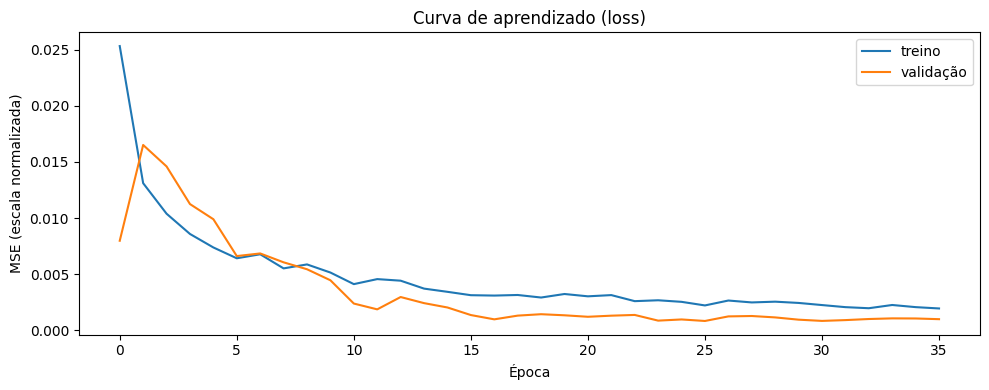

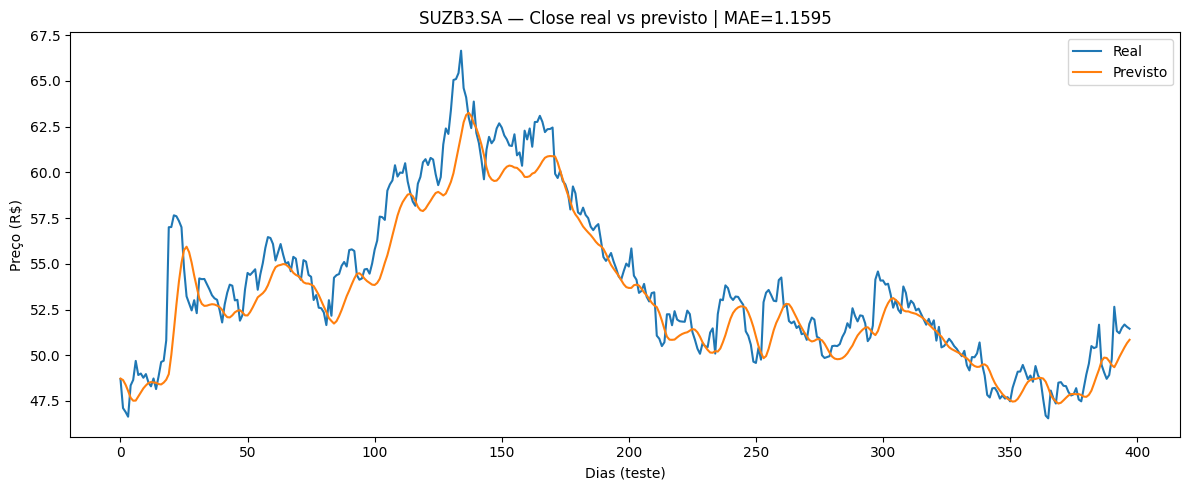

In [11]:
pred_scaled = model.predict(dataset.X_test, verbose=0)
y_pred = dataset.scaler.inverse_transform(pred_scaled).ravel()
y_true = dataset.scaler.inverse_transform(dataset.y_test.reshape(-1, 1)).ravel()

metrics = regression_metrics(y_true, y_pred)
baseline = naive_baseline(y_true)
print(f"LSTM    : {metrics}")
print(f"Baseline: {baseline}")

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="treino")
plt.plot(history.history["val_loss"], label="validação")
plt.title("Curva de aprendizado (loss)")
plt.xlabel("Época")
plt.ylabel("MSE (escala normalizada)")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "learning_curve.png", dpi=120)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Previsto")
plt.title(f"{dataset.symbol} — Close real vs previsto | MAE={metrics['MAE']}")
plt.xlabel("Dias (teste)")
plt.ylabel("Preço (R$)")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "pred_vs_real.png", dpi=120)
plt.show()

### 9.4 Persistência dos artefatos

In [12]:
model_path = MODELS_DIR / "lstm_stock.keras"
scaler_path = MODELS_DIR / "scaler.pkl"
meta_path = MODELS_DIR / "metadata.json"

model.save(model_path)
joblib.dump(dataset.scaler, scaler_path)

last_window_real = dataset.raw_close.tail(dataset.window).astype(float).tolist()

meta = {
    "symbol": dataset.symbol,
    "window": dataset.window,
    "features": ["Close"],
    "train_start": dataset.train_start,
    "train_end": dataset.train_end,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "epochs_max": EPOCHS,
        "patience": PATIENCE,
    },
    "metrics": metrics,
    "baseline_naive": baseline,
    "framework": "keras",
    "n_train_samples": int(dataset.X_train.shape[0]),
    "n_test_samples": int(dataset.X_test.shape[0]),
    "last_window_real": last_window_real,
    "saved_at": dt.datetime.now(dt.UTC).isoformat(),
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print(f"modelo:   {model_path}")
print(f"scaler:   {scaler_path}")
print(f"metadata: {meta_path}")
print(f"Métricas finais: {metrics}")

modelo:   models/lstm_stock.keras
scaler:   models/scaler.pkl
metadata: models/metadata.json
Métricas finais: {'MAE': 1.1595, 'RMSE': 1.5877, 'MAPE_%': 2.0998}
